# 06 — Calculate General Interest Rate Risk (GIRR) delta

Calculate interest-rate sensitivity by currency and prescribed tenor, including the separate flat inflation and cross-currency basis factors.

Present Value of One Basis Point (PV01) is the value change for a one-basis-point interest-rate movement. One basis point is 0.01 percentage point, or 0.0001 in decimal form. Ordinary yield-curve factors use Basel tenors; inflation and cross-currency basis are flat factors for which tenor is not applicable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

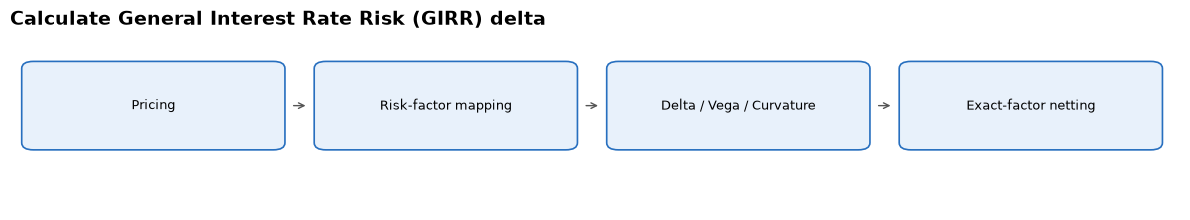

In [2]:
draw_flow(['Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting'],'Calculate General Interest Rate Risk (GIRR) delta',wrap_after=4)

Bump one curve factor, hold everything else constant, reprice the trade and divide the value change by the bump. A cross-currency swap is mapped to both relevant currency curves, its basis factor and FX risk.

$$s_k=\frac{V(r_k+0.0001)-V(r_k)}{0.0001}$$

In [3]:
from frtb_engine.parameters import risk_weight
delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
view=delta[delta.risk_class=='GIRR'].copy()
view['value_change_for_bump_inr']=view.shocked_value_inr-view.base_value_inr
view['applicable_risk_weight']=view.apply(lambda row:risk_weight(row.to_dict(),'DELTA'),axis=1)
view['tenor_display']=view.apply(
    lambda row: f"{row.tenor:g} years" if row.factor_type=='standard'
    else ('Not applicable — flat inflation factor' if row.factor_type=='inflation'
          else 'Not applicable — flat cross-currency basis factor'),axis=1)
view['factor_label']=view.apply(
    lambda row: f"{row.bucket} OIS — {row.tenor:g}Y" if row.factor_type=='standard'
    else (f"{row.bucket} inflation — flat" if row.factor_type=='inflation'
          else f"{row.risk_factor_id.replace('_',' ')} — flat"),axis=1)
columns=['trade_id','instrument_type','currency','bucket','risk_factor_id','factor_type','tenor_display',
         'applicable_risk_weight','base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity']
shown=crore_table(view[columns],['base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity'])
display_sample(percent_columns(shown,['applicable_risk_weight']),30)
print('The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.')
example=view.iloc[0]
print()
print(f"Worked trade: {example.trade_id} | factor: {example.risk_factor_id}")
print(f"Base value: INR {example.base_value_inr/INR_CRORE:,.4f} crore")
print(f"Shocked value: INR {example.shocked_value_inr/INR_CRORE:,.4f} crore")
print(f"Value change for +1 bp: INR {example.value_change_for_bump_inr:,.2f}")
print(f"Sensitivity = value change / 0.0001 = INR {example.raw_sensitivity:,.2f} per unit rate change")

Displayed rows: first 30 of 47 observations, in table order.


,trade_id,instrument_type,currency,bucket,risk_factor_id,factor_type,tenor_display,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),Value Change For Bump (INR crore),Raw Sensitivity (INR crore per unit change)
0,R01,BOND,INR,INR,INR_OIS_2.0Y,standard,2 years,1.3000,9.9608,9.9589,-0.0019,-19.3106
1,R02,BOND,INR,INR,INR_OIS_5.0Y,standard,5 years,1.1000,15.0434,15.0368,-0.0066,-65.9979
2,R03,BOND,INR,INR,INR_OIS_10.0Y,standard,10 years,1.1000,-12.0472,-12.0382,0.0090,89.9005
3,R04,BOND,USD,USD,USD_OIS_5.0Y,standard,5 years,1.1000,17.2911,17.2832,-0.0080,-79.7535
5,R05,BOND,EUR,EUR,EUR_OIS_10.0Y,standard,10 years,1.1000,16.4608,16.4463,-0.0146,-145.5209
7,R06,IRS,INR,INR,INR_OIS_5.0Y,standard,5 years,1.1000,-0.0715,-0.0786,-0.0071,-71.1405
8,R07,IRS,USD,USD,USD_OIS_10.0Y,standard,10 years,1.1000,0.0000,0.0171,0.0171,171.4484
10,R08,FRA,INR,INR,INR_OIS_0.5Y,standard,0.5 years,1.7000,-0.0048,-0.0044,0.0005,4.8494
11,R09,SWAPTION,INR,INR,INR_OIS_5.0Y,standard,5 years,1.1000,0.4181,0.4214,0.0033,32.7934
12,R10,SWAPTION,USD,USD,USD_OIS_10.0Y,standard,10 years,1.1000,1.0027,0.9934,-0.0093,-93.2898


The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.

Worked trade: R01 | factor: INR_OIS_2.0Y
Base value: INR 9.9608 crore
Shocked value: INR 9.9589 crore
Value change for +1 bp: INR -19,310.63
Sensitivity = value change / 0.0001 = INR -193,106,258.58 per unit rate change


The visual below uses the calculated rows shown above.

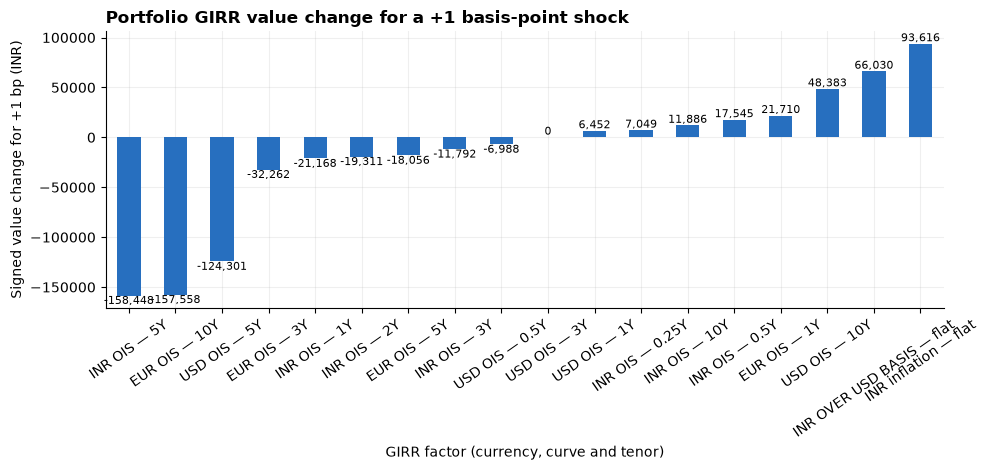

In [4]:
effect=view.groupby('factor_label',dropna=False)['value_change_for_bump_inr'].sum().sort_values()
bar_inr(effect,'Portfolio GIRR value change for a +1 basis-point shock',
        x_axis_label='GIRR factor (currency, curve and tenor)',
        y_axis_label='Signed value change for +1 bp (INR)')

GIRR rows remain trade-level and tenor-specific until exact-factor netting.